# Utilities

In [1]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from Utils.Config import ExperimentResult
from pprint import pprint


json_path = Path("Cache/MetaData/trial_0034/experiment_summary.json")

with open(json_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

exp = ExperimentResult.from_jsonable(raw)

pprint(exp)

ExperimentResult(transform_hparams=TransformHyperParams(resize_size=224,
                                                        p=1.0,
                                                        prefix='resizecrop',
                                                        bilateral_d=11,
                                                        sigma_color=170,
                                                        sigma_space=75,
                                                        gaussian_k=11,
                                                        gaussian_sigma=2.0,
                                                        nlmeans_h=20,
                                                        template_window_size=11,
                                                        search_window_size=11,
                                                        gray_alpha=1.0,
                                                        grid_size=6,
                                                    

In [3]:
# =========================================================
# Trial utilities
# =========================================================

from typing import Iterable


def format_trial_id(trial_id: int | str) -> str:
    if isinstance(trial_id, int):
        return f"{trial_id:04d}"
    trial_id = str(trial_id)
    if trial_id.startswith("trial_"):
        trial_id = trial_id.replace("trial_", "")
    return trial_id.zfill(4)


def build_trial_json_path(meta_root: str | Path, trial_id: int | str) -> Path:
    trial_id_str = format_trial_id(trial_id)
    return Path(meta_root) / f"trial_{trial_id_str}" / "experiment_summary.json"


def resolve_trial_json_paths(
    meta_root: str | Path,
    trial_ids: Optional[Iterable[int | str]] = None,
    trial_start: Optional[int] = None,
    trial_end: Optional[int] = None,
) -> List[Path]:
    """
    Priority:
      1) if trial_ids is given, use those exact trials
      2) elif trial_start/trial_end given, use inclusive range
      3) else, use all trial_*/experiment_summary.json
    """
    meta_root = Path(meta_root)

    if trial_ids is not None:
        paths = [build_trial_json_path(meta_root, tid) for tid in trial_ids]
        return [p for p in paths if p.exists()]

    if trial_start is not None or trial_end is not None:
        if trial_start is None or trial_end is None:
            raise ValueError("Both trial_start and trial_end must be provided together.")
        if trial_start > trial_end:
            raise ValueError("trial_start must be <= trial_end.")

        paths = [
            build_trial_json_path(meta_root, tid)
            for tid in range(trial_start, trial_end + 1)
        ]
        return [p for p in paths if p.exists()]

    return sorted(meta_root.glob("trial_*/experiment_summary.json"))


def parse_trial_id_from_path(path: Path) -> str:
    # .../trial_0034/experiment_summary.json -> "0034"
    return path.parent.name.replace("trial_", "")


def load_experiment_result(path: str | Path) -> ExperimentResult:
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    return ExperimentResult.from_jsonable(raw)

In [4]:
# =========================================================
# Localwarp extraction
# =========================================================

from Utils.Config import ModelRunResult, ScenarioRecord


def get_localwarp_validation_metrics(exp: ExperimentResult) -> Dict[str, Any]:
    out = {
        "target_feature": None,
        "config_hash": None,
        "lv": None,
        "hfe": None,
        "essim": None,
        "gc": None,
        "texture_score": None,
        "shape_score": None,
    }

    if exp.perturbation_validation is None:
        return out

    lw = exp.perturbation_validation.results.get("localwarp")
    if lw is None:
        return out

    metrics = lw.metrics or {}

    def pick(*keys):
        for k in keys:
            if k in metrics and metrics[k] is not None:
                return metrics[k]
        return None

    out["config_hash"] = lw.config_hash
    out["target_feature"] = pick("feature", "target_feature")

    out["lv"] = pick("LV", "lv", "LV_ratio", "lv_ratio")
    out["hfe"] = pick("HFE", "hfe", "HFE_ratio", "hfe_ratio")
    out["essim"] = pick("ESSIM", "essim")
    out["gc"] = pick("GC", "gc")
    out["texture_score"] = pick("texture_score")
    out["shape_score"] = pick("shape_score")

    return out


def get_model_localwarp_record(
    model_run: ModelRunResult,
    dataset_name: str = "imagenet",
    perturbation: str = "localwarp",
) -> Optional[ScenarioRecord]:
    """
    Prefer exact scenario_name = '{dataset_name}__{perturbation}'.
    Fallback to matching by record fields.
    """
    exact_key = f"{dataset_name}__{perturbation}"
    if exact_key in model_run.scenario_results:
        return model_run.scenario_results[exact_key]

    for _, rec in model_run.scenario_results.items():
        if rec.dataset_name == dataset_name and rec.perturbation == perturbation:
            return rec

    return None


def build_localwarp_summary_row(
    exp: ExperimentResult,
    trial_id: str,
    dataset_name: str = "imagenet",
) -> Dict[str, Any]:
    """
    Build one summary row per trial.
    Wide format:
      - one row per trial
      - validation metrics as shared columns
      - model-wise metrics expanded into columns
    """
    th = exp.transform_hparams
    val = get_localwarp_validation_metrics(exp)

    row: Dict[str, Any] = {
        "trial_id": trial_id,
        "alpha_localwarp": th.alpha_localwarp,
        "sigma_localwarp": th.sigma_localwarp,
        "grid_size": th.grid_size,

        "target_feature": val["target_feature"],
        "config_hash": val["config_hash"],
        "LV_ratio": val["lv"],
        "HFE_ratio": val["hfe"],
        "ESSIM": val["essim"],
        "gc": val["gc"],
        "texture_score": val["texture_score"],
        "shape_score": val["shape_score"],
    }

    for model_key, model_run in exp.model_results.items():
        rec = get_model_localwarp_record(
            model_run=model_run,
            dataset_name=dataset_name,
            perturbation="localwarp",
        )

        prefix = model_key
        row[f"{prefix}_model_name"] = model_run.model_name
        row[f"{prefix}_pretrained_weight"] = model_run.pretrained_weight

        if rec is None:
            row[f"{prefix}_scenario_name"] = None
            row[f"{prefix}_accuracy"] = None
            row[f"{prefix}_relative_accuracy_score"] = None
            row[f"{prefix}_js_divergence"] = None
            row[f"{prefix}_cka"] = None
            row[f"{prefix}_accuracy_drop_vs_same_dataset_clean"] = None
            row[f"{prefix}_accuracy_drop_vs_id_clean"] = None
            row[f"{prefix}_ood_gap_vs_id_clean"] = None
            row[f"{prefix}_intervention_gain_vs_same_dataset_clean"] = None
            continue

        row[f"{prefix}_scenario_name"] = rec.scenario_name
        row[f"{prefix}_accuracy"] = rec.accuracy
        row[f"{prefix}_relative_accuracy_score"] = rec.relative_accuracy_score
        row[f"{prefix}_js_divergence"] = rec.js_divergence
        row[f"{prefix}_cka"] = rec.cka
        row[f"{prefix}_accuracy_drop_vs_same_dataset_clean"] = rec.accuracy_drop_vs_same_dataset_clean
        row[f"{prefix}_accuracy_drop_vs_id_clean"] = rec.accuracy_drop_vs_id_clean
        row[f"{prefix}_ood_gap_vs_id_clean"] = rec.ood_gap_vs_id_clean
        row[f"{prefix}_intervention_gain_vs_same_dataset_clean"] = rec.intervention_gain_vs_same_dataset_clean

    return row


# =========================================================
# Main builder
# =========================================================

def build_localwarp_summary_dataframe(
    meta_root: str | Path = "Cache/MetaData",
    trial_ids: Optional[Iterable[int | str]] = None,
    trial_start: Optional[int] = None,
    trial_end: Optional[int] = None,
    dataset_name: str = "imagenet",
    sort_by: Optional[List[str]] = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Build localwarp summary DataFrame from multiple trials.

    Ways to specify trials:
      - trial_ids=[34, 35, 36]
      - trial_start=34, trial_end=36
      - neither -> all trials
    """
    json_paths = resolve_trial_json_paths(
        meta_root=meta_root,
        trial_ids=trial_ids,
        trial_start=trial_start,
        trial_end=trial_end,
    )

    if verbose:
        print(f"[Info] Found {len(json_paths)} trial json files.")

    rows: List[Dict[str, Any]] = []

    for path in json_paths:
        trial_id = parse_trial_id_from_path(path)

        try:
            exp = load_experiment_result(path)
            row = build_localwarp_summary_row(
                exp=exp,
                trial_id=trial_id,
                dataset_name=dataset_name,
            )
            rows.append(row)

        except Exception as e:
            if verbose:
                print(f"[Warn] Failed to parse trial_{trial_id}: {e}")

    df = pd.DataFrame(rows)

    if len(df) == 0:
        if verbose:
            print("[Warn] localwarp summary dataframe is empty.")
        return df

    if sort_by is None:
        sort_by = ["alpha_localwarp", "sigma_localwarp", "trial_id"]

    existing_sort_by = [c for c in sort_by if c in df.columns]
    if existing_sort_by:
        df = df.sort_values(existing_sort_by).reset_index(drop=True)

    return df

In [5]:
from Utils.utils import ensure_dir

trial_start, trial_end = 2, 37

df = build_localwarp_summary_dataframe(
    meta_root="Cache/MetaData",
    trial_start=trial_start,
    trial_end=trial_end
)
print(df.shape)
print(df.head())

ensure_dir('Cache/Analysis')
df.to_csv(f'Cache/Analysis/localwarp_trial{trial_start}~{trial_end}.csv')

[Info] Found 35 trial json files.
(35, 34)
  trial_id  alpha_localwarp  sigma_localwarp  grid_size target_feature  \
0     0002                0              0.5          6           None   
1     0003                0              1.0          6           None   
2     0004                0              2.0          6           None   
3     0005                0              3.5          6           None   
4     0006                0              6.0          6           None   

    config_hash  LV_ratio  HFE_ratio  ESSIM   gc  ...  \
0  4d7da57342ff  0.999999        1.0    1.0  1.0  ...   
1  67b582b76657  0.999999        1.0    1.0  1.0  ...   
2  c398d7e8ce0e  0.999999        1.0    1.0  1.0  ...   
3  e4e45aa47fb6  0.999999        1.0    1.0  1.0  ...   
4  c7c6e8777e7f  0.999999        1.0    1.0  1.0  ...   

   vit-b__augreg_in1k_pretrained_weight  vit-b__augreg_in1k_scenario_name  \
0                           augreg_in1k               imagenet__localwarp   
1              

In [6]:
import matplotlib.pyplot as plt


def plot_localwarp_two_panel_from_csv(df, alpha, save_path=None):
    sub = df[df["alpha_localwarp"] == alpha].copy()

    if len(sub) == 0:
        raise ValueError(f"No rows found for alpha_localwarp={alpha}")

    sub = sub.sort_values("sigma_localwarp")

    x = sub["sigma_localwarp"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    # Left: feature scores
    axes[0].plot(x, sub["shape_score"], marker="o", linewidth=2, markersize=4, label="shape_score")
    axes[0].plot(x, sub["texture_score"], marker="o", linewidth=2, markersize=4, label="texture_score")

    axes[0].set_xlabel("sigma_localwarp")
    axes[0].set_ylabel("score")
    axes[0].set_title("Feature Suppression Trend")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Right: model accuracies
    axes[1].plot(
        x,
        sub["resnet50__in1k_accuracy"],
        marker="o",
        linewidth=2,
        markersize=4,
        label="resnet50__in1k",
    )
    axes[1].plot(
        x,
        sub["vit-b__augreg_in1k_accuracy"],
        marker="o",
        linewidth=2,
        markersize=4,
        label="vit-b__augreg_in1k",
    )

    axes[1].set_xlabel("sigma_localwarp")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title("Model Performance")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def plot_scatter_shape_vs_accuracy(df):
    alphas = sorted(df["alpha_localwarp"].unique())

    n = len(alphas)
    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, alpha in enumerate(alphas):
        ax = axes[i]
        sub = df[df["alpha_localwarp"] == alpha]

        # ResNet
        ax.scatter(
            sub["shape_score"],
            sub["resnet50__in1k_accuracy"],
            label="ResNet-50",
            alpha=0.7
        )

        # ViT
        ax.scatter(
            sub["shape_score"],
            sub["vit-b__augreg_in1k_accuracy"],
            label="ViT-B",
            alpha=0.7
        )

        ax.set_title(f"alpha={alpha}")
        ax.set_xlabel("shape_score")
        ax.set_ylabel("accuracy")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    
def plot_scatter_texture_vs_accuracy(df):
    import matplotlib.pyplot as plt
    import numpy as np

    alphas = sorted(df["alpha_localwarp"].unique())

    n = len(alphas)
    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, alpha in enumerate(alphas):
        ax = axes[i]
        sub = df[df["alpha_localwarp"] == alpha]

        ax.scatter(sub["texture_score"], sub["resnet50__in1k_accuracy"], label="ResNet-50")
        ax.scatter(sub["texture_score"], sub["vit-b__augreg_in1k_accuracy"], label="ViT-B")

        ax.set_title(f"alpha={alpha}")
        ax.set_xlabel("texture_score")
        ax.set_ylabel("accuracy")
        ax.grid(True, alpha=0.3)
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [8]:
def compute_correlation_table(df):
    rows = []

    for alpha in sorted(df["alpha_localwarp"].unique()):
        sub = df[df["alpha_localwarp"] == alpha]

        if len(sub) < 2:
            continue

        # ResNet
        corr_shape_resnet = sub["shape_score"].corr(sub["resnet50__in1k_accuracy"])
        corr_texture_resnet = sub["texture_score"].corr(sub["resnet50__in1k_accuracy"])

        # ViT
        corr_shape_vit = sub["shape_score"].corr(sub["vit-b__augreg_in1k_accuracy"])
        corr_texture_vit = sub["texture_score"].corr(sub["vit-b__augreg_in1k_accuracy"])

        rows.append({
            "alpha": alpha,

            "shape_vs_resnet": corr_shape_resnet,
            "texture_vs_resnet": corr_texture_resnet,

            "shape_vs_vit": corr_shape_vit,
            "texture_vs_vit": corr_texture_vit,
        })

    return pd.DataFrame(rows)

In [9]:
from Experiment import alpha_grid

for alpha in alpha_grid:
    plot_localwarp_two_panel_from_csv(
        df,
        alpha=alpha,
        save_path=f"localwarp_alpha_{alpha}_sigma_trend.png"
    )

In [3]:
from pathlib import Path

root = Path("Data/imagenet-r")

num_classes = len([p for p in root.glob("*") if p.is_dir()])
print(num_classes)

set_classes = set([p for p in root.glob("*") if p.is_dir()])
print(len(set_classes))

200
200


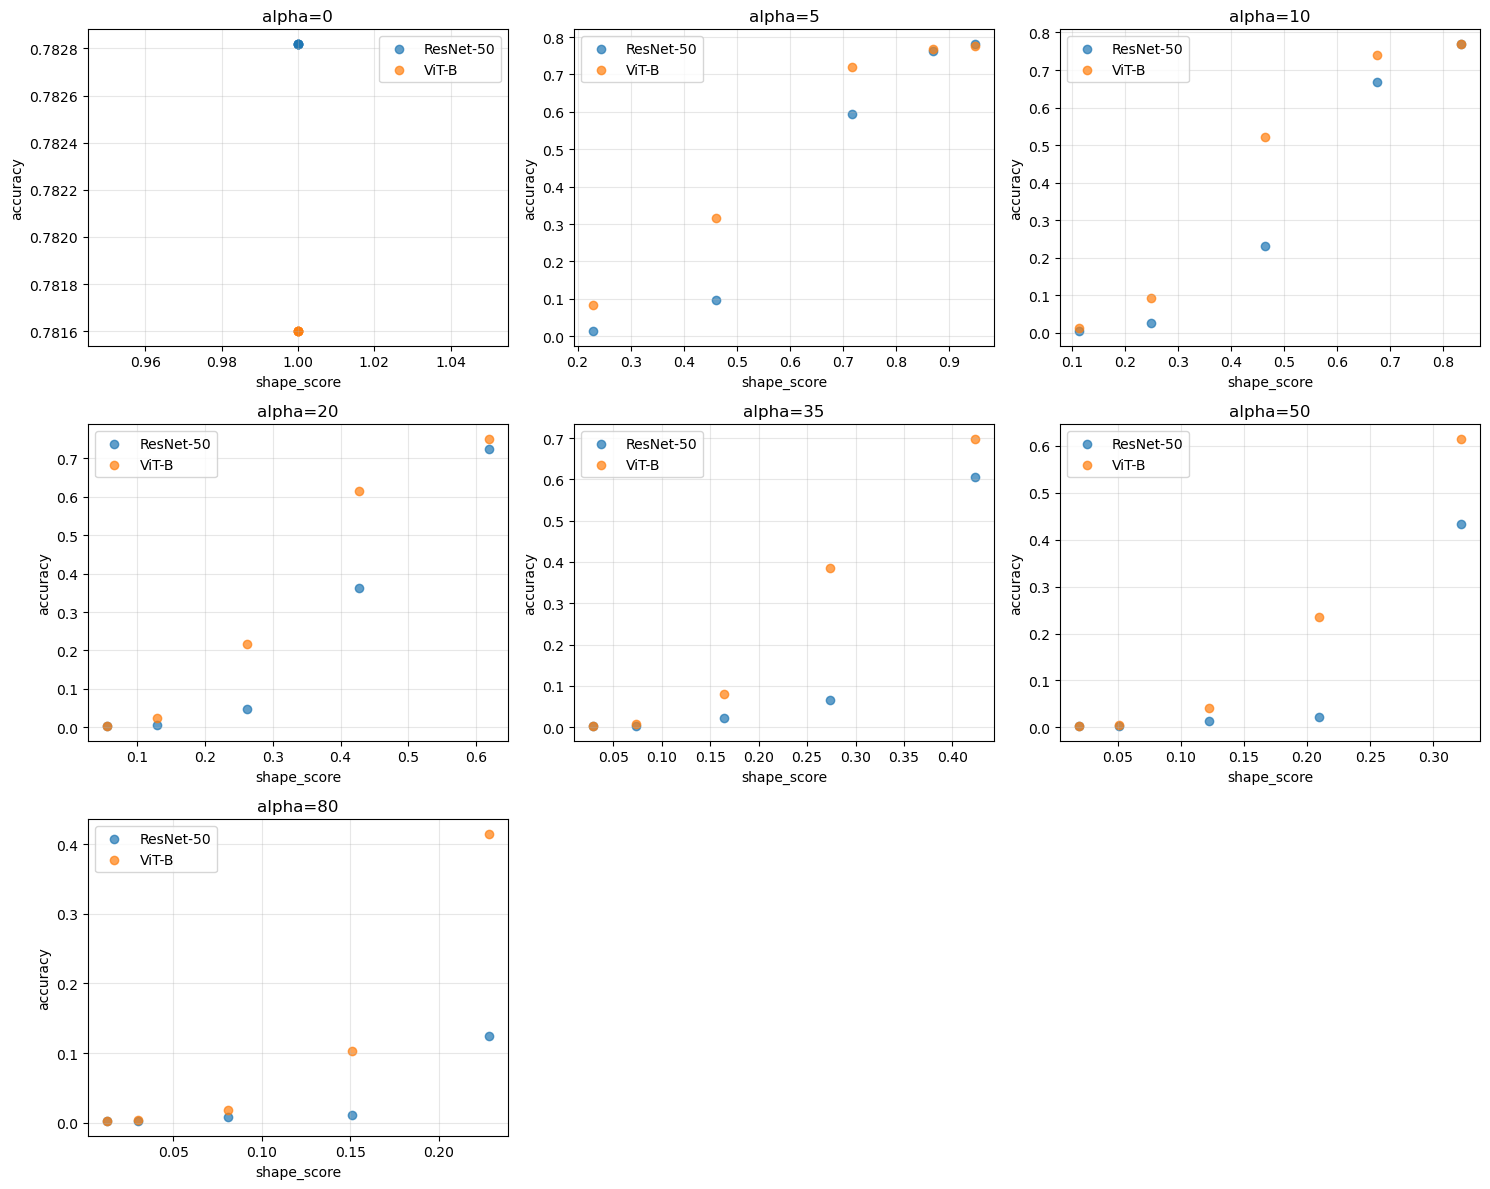

   alpha  shape_vs_resnet  texture_vs_resnet  shape_vs_vit  texture_vs_vit
0      0              NaN                NaN           NaN             NaN
1      5         0.974814          -0.781456      0.976743       -0.893268
2     10         0.972526          -0.875496      0.971698       -0.981734
3     20         0.957151          -0.891601      0.979877       -0.988679
4     35         0.861267          -0.824785      0.976756       -0.987916
5     50         0.829140          -0.911509      0.950917       -0.996048
6     80         0.836339          -0.992226      0.910220       -0.997739


/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [ ]:

# 1. scatter
plot_scatter_shape_vs_accuracy(df)



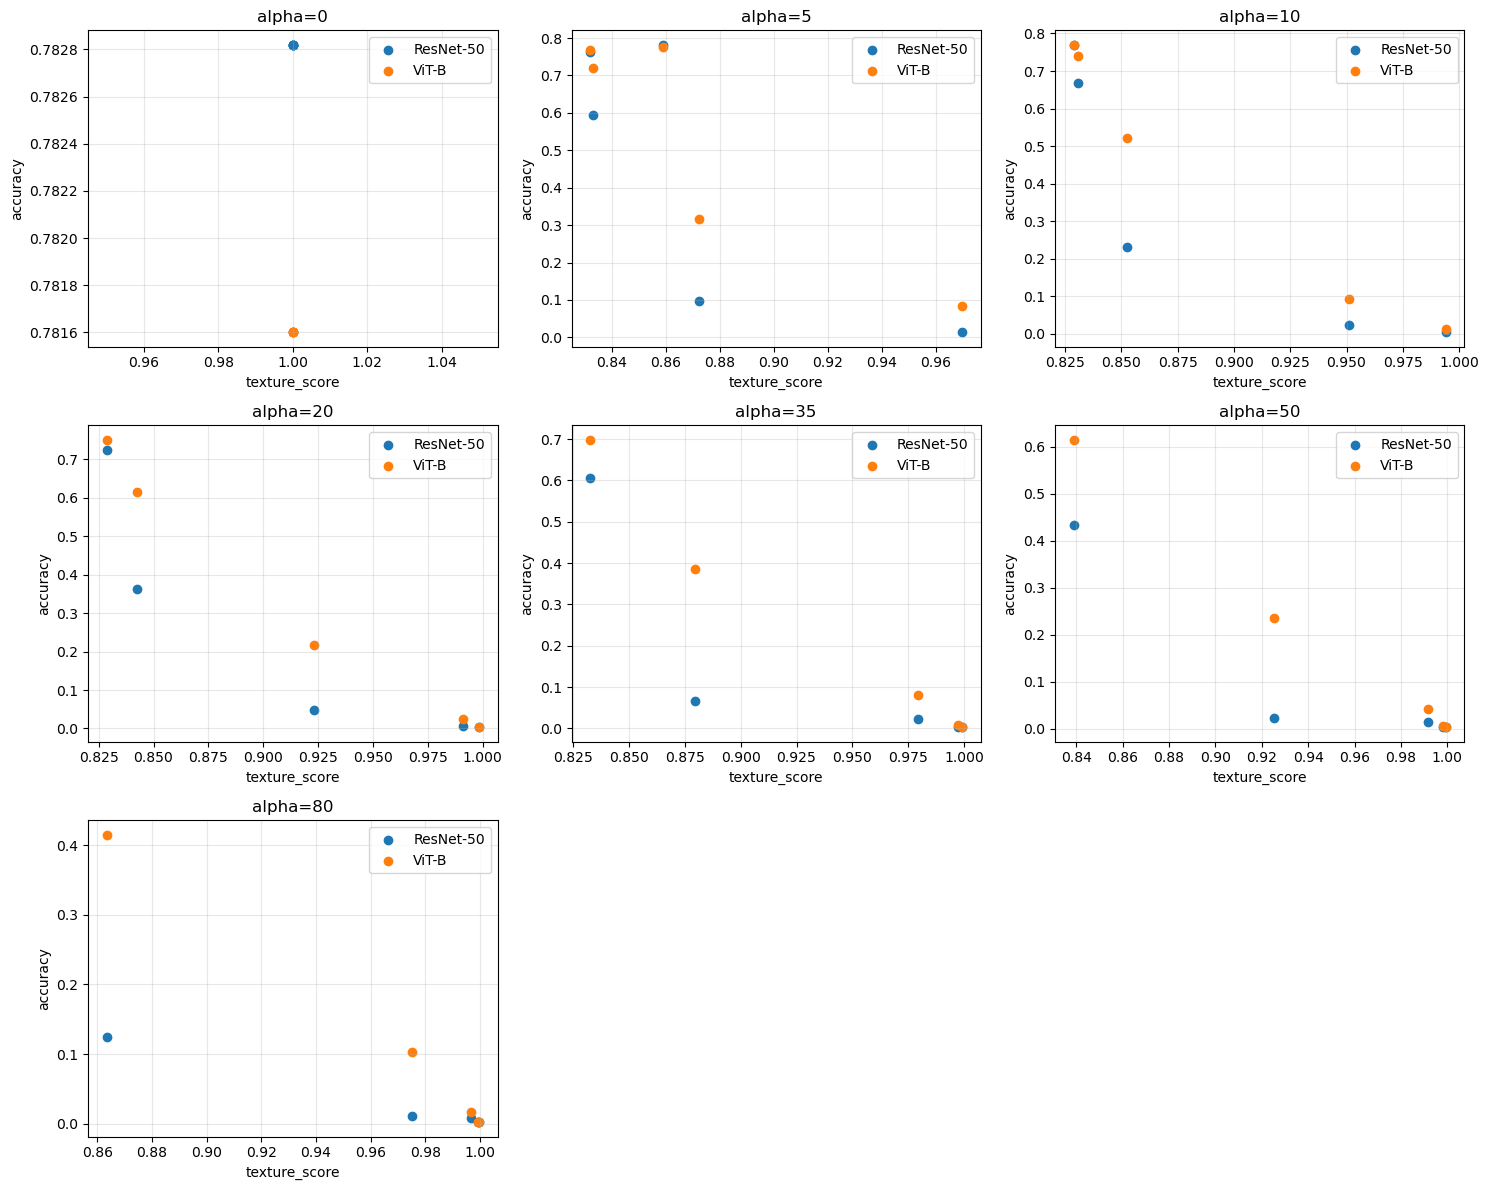

In [11]:
plot_scatter_texture_vs_accuracy(df)

In [12]:
# 2. correlation
corr_df = compute_correlation_table(df)
display(corr_df)

/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,alpha,shape_vs_resnet,texture_vs_resnet,shape_vs_vit,texture_vs_vit
0,0,NaN,NaN,NaN,NaN
1,5,0.974814,-0.781456,0.976743,-0.893268
2,10,0.972526,-0.875496,0.971698,-0.981734
3,20,0.957151,-0.891601,0.979877,-0.988679
4,35,0.861267,-0.824785,0.976756,-0.987916
5,50,0.829140,-0.911509,0.950917,-0.996048
6,80,0.836339,-0.992226,0.910220,-0.997739


In [15]:
from sklearn.linear_model import LinearRegression
import pandas as pd


def run_regression(df):
    results = []

    for alpha in sorted(df["alpha_localwarp"].unique()):
        sub = df[df["alpha_localwarp"] == alpha]

        if len(sub) < 3:
            continue

        X = sub[["shape_score", "texture_score"]].values

        # ResNet
        y_resnet = sub["resnet50__in1k_accuracy"].values
        model_r = LinearRegression().fit(X, y_resnet)

        # ViT
        y_vit = sub["vit-b__augreg_in1k_accuracy"].values
        model_v = LinearRegression().fit(X, y_vit)

        results.append({
            "alpha": alpha,

            "resnet_shape_coef": model_r.coef_[0],
            "resnet_texture_coef": model_r.coef_[1],

            "vit_shape_coef": model_v.coef_[0],
            "vit_texture_coef": model_v.coef_[1],
        })

    return pd.DataFrame(results)

In [16]:
run_regression(df)

,alpha,resnet_shape_coef,resnet_texture_coef,vit_shape_coef,vit_texture_coef
0,0,0.000000,0.000000,0.000000,0.000000
1,5,1.325331,0.749145,0.810828,-1.409194
2,10,1.562926,1.561610,0.506740,-2.744768
3,20,1.999093,2.002902,0.554839,-2.713201
4,35,1.645676,0.491808,0.616961,-2.667373
5,50,-0.868840,-3.942976,-0.118267,-3.932216
6,80,-0.105972,-1.036020,0.263547,-2.644128


In [20]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


def standardize_features(df):
    scaler = StandardScaler()

    X = df[["shape_score", "texture_score"]].values
    X_scaled = scaler.fit_transform(X)

    return X_scaled

def run_ridge(df, alpha_ridge=1.0):
    results = []

    for alpha in sorted(df["alpha_localwarp"].unique()):
        sub = df[df["alpha_localwarp"] == alpha]

        if len(sub) < 3:
            continue

        # X (standardized)
        scaler = StandardScaler()
        X = scaler.fit_transform(sub[["shape_score", "texture_score"]])

        # ResNet
        y_r = sub["resnet50__in1k_accuracy"].values
        model_r = Ridge(alpha=alpha_ridge).fit(X, y_r)

        # ViT
        y_v = sub["vit-b__augreg_in1k_accuracy"].values
        model_v = Ridge(alpha=alpha_ridge).fit(X, y_v)

        results.append({
            "alpha": alpha,

            "resnet_shape_coef": model_r.coef_[0],
            "resnet_texture_coef": model_r.coef_[1],

            "vit_shape_coef": model_v.coef_[0],
            "vit_texture_coef": model_v.coef_[1],
        })

    return pd.DataFrame(results)

def partial_corr(x, y, z):
    """
    Compute partial correlation corr(x, y | z)
    """

    # x ~ z
    model_x = LinearRegression().fit(z.reshape(-1, 1), x)
    x_res = x - model_x.predict(z.reshape(-1, 1))

    # y ~ z
    model_y = LinearRegression().fit(z.reshape(-1, 1), y)
    y_res = y - model_y.predict(z.reshape(-1, 1))

    # residual correlation
    return np.corrcoef(x_res, y_res)[0, 1]

def compute_partial_correlations(df):
    rows = []

    for alpha in sorted(df["alpha_localwarp"].unique()):
        sub = df[df["alpha_localwarp"] == alpha]

        if len(sub) < 3:
            continue

        shape = sub["shape_score"].values
        texture = sub["texture_score"].values

        acc_r = sub["resnet50__in1k_accuracy"].values
        acc_v = sub["vit-b__augreg_in1k_accuracy"].values

        # shape | texture
        pcorr_r = partial_corr(shape, acc_r, texture)
        pcorr_v = partial_corr(shape, acc_v, texture)

        # texture | shape
        pcorr_tex_r = partial_corr(texture, acc_r, shape)
        pcorr_tex_v = partial_corr(texture, acc_v, shape)

        rows.append({
            "alpha": alpha,

            "shape|texture_resnet": pcorr_r,
            "shape|texture_vit": pcorr_v,

            "texture|shape_resnet": pcorr_tex_r,
            "texture|shape_vit": pcorr_tex_v,
        })

    return pd.DataFrame(rows)

In [19]:
run_ridge(df)

,alpha,resnet_shape_coef,resnet_texture_coef,vit_shape_coef,vit_texture_coef
0,0,0.000000,0.000000,0.000000,0.000000
1,5,0.229961,-0.054320,0.162120,-0.097167
2,10,0.198732,-0.078833,0.139216,-0.151505
3,20,0.159869,-0.080730,0.133583,-0.145145
4,35,0.109405,-0.072585,0.116210,-0.129248
5,50,0.039340,-0.097312,0.083577,-0.127426
6,80,0.009138,-0.032367,0.050493,-0.094007


In [21]:
compute_partial_correlations(df)

/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/user/miniconda3/envs/feature_reliance/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,alpha,shape|texture_resnet,shape|texture_vit,texture|shape_resnet,texture|shape_vit
0,0,NaN,NaN,NaN,NaN
1,5,0.939385,0.931262,0.282552,-0.645376
2,10,0.906968,0.753749,0.485369,-0.848449
3,20,0.820854,0.631942,0.449925,-0.812756
4,35,0.443223,0.523738,0.070920,-0.787784
5,50,-0.388018,-0.177166,-0.735015,-0.959271
6,80,-0.676266,0.933242,-0.985919,-0.998299
